                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept t

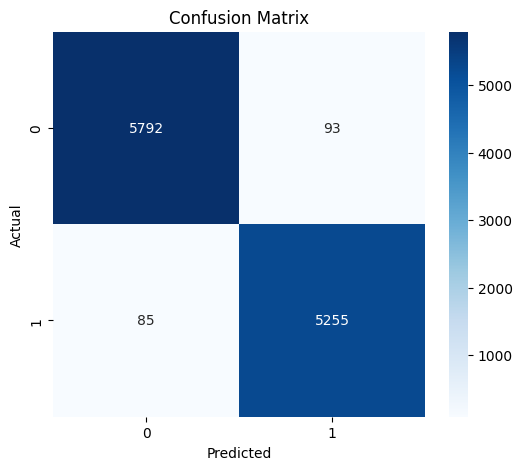

Fake News
Fake News


In [ ]:

# Fake News Detection using Machine Learning


# Import required libraries
import pandas as pd
import numpy as np
import string
import re

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
#  Load the datasets

fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

# Display first five rows
print(fake.head())
print(true.head())

#  Add labels

fake["label"] = 0
true["label"] = 1


#  Merge both datasets

data = pd.concat([fake, true], axis=0)

# Display dataset size
print("Dataset Shape:", data.shape)


# Step 4: Shuffle the dataset

data = data.sample(frac=1)

# Reset index
data.reset_index(drop=True, inplace=True)


#  Keep only required columns

data = data[["title", "text", "label"]]


# Step 6: Check missing values

print(data.isnull().sum())

# Remove missing values
data = data.dropna()


#  Clean the news text

def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove text inside square brackets
    text = re.sub(r'\[.*?\]', '', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>+', '', text)

    # Remove punctuation
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)

    # Remove newline characters
    text = re.sub(r'\n', '', text)

    # Remove numbers
    text = re.sub(r'\w*\d\w*', '', text)

    return text

# Apply cleaning function
data["text"] = data["text"].apply(clean_text)

 
#  Separate Features and Labels

x = data["text"]
y = data["label"]


#  Split dataset into Training & Testing

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42
)
#  Convert text into numerical values
# using TF-IDF Vectorizer

vectorizer = TfidfVectorizer(stop_words="english")

xv_train = vectorizer.fit_transform(x_train)
xv_test = vectorizer.transform(x_test)


#  Train Logistic Regression Model

model = LogisticRegression()

model.fit(xv_train, y_train)


#  Predict on test data

prediction = model.predict(xv_test)

# Step 13: Calculate Accuracy

accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", accuracy)


#  Print Classification Report

print(classification_report(y_test, prediction))


 #Create Confusion Matrix

cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Predict Custom News

def predict_news(news):

    # Clean input text
    news = clean_text(news)

    # Convert into TF-IDF vector
    news = vectorizer.transform([news])

    # Predict result
    prediction = model.predict(news)

    if prediction[0] == 0:
        print("Fake News")
    else:
        print("Real News")


# Test with your own news


predict_news("NASA successfully launched a new satellite into space today.")

predict_news("Aliens landed in India and gifted everyone unlimited gold.")